# NYC 311 record-answerability: evidence walkthrough

This notebook reads the files the pipeline published (`output/run_date=2026-09-25/`) and the snapshot manifest. It does not recompute the pipeline; run `python3 run_pipeline.py --run-date 2026-09-25 --snapshot-id 20260925T112431Z_initial` for that. Sections follow the rubric: retrieval, validation, workflow model, metrics, decision.

In [1]:
import json, sqlite3
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUT = ROOT / "output" / "run_date=2026-09-25"
SNAP = ROOT / "data" / "raw" / "snapshots" / "20260925T112431Z_initial"
pd.set_option("display.max_colwidth", 90)
BLUE, ORANGE = "#2a78d6", "#eb6834"   # categorical slots 1 and 2 (validated palette)

## 1. Retrieval: did we get every row?
Each dataset's received rows are compared with the API's own `count(*)`. Every raw page is stored with its SHA-256.

In [2]:
man = json.loads((SNAP / "manifest.json").read_text())
pd.DataFrame([{"dataset": k, "dataset_id": v["dataset_id"], "method": v["method"], "pages": len(v["files"]),
               "expected (API count)": v["expected_count"], "received": v["received_rows"],
               "match": v["expected_count"] == v["received_rows"], "source last updated (UTC)": v["rows_updated_at_utc"][:10]}
              for k, v in man["datasets"].items()])

,dataset,dataset_id,method,pages,expected (API count),received,match,source last updated (UTC)
0,call_center,wewp-mm3p,offset,20,950999,950999,True,2026-09-25
1,service_requests,erm2-nwe9,offset,20,969004,969004,True,2026-09-25
2,sla,cs9t-e3x8,offset,1,3563,3563,True,2024-03-05
3,survey,5ijn-vbdv,offset,6,275467,275467,True,2026-09-21


## 2. Validation: the gate
Every rule has a severity for weekly reporting and one for a live answer to a resident.

In [3]:
rep = json.loads((OUT / "validation_report.json").read_text())
print("Weekly reporting:", rep["gate"]["reporting_gate"], "| Live answers:", rep["gate"]["live_answer_gate"])
pd.DataFrame([{"rule": r["id"], "check": r["name"], "reporting": r["reporting"], "live": r["live"],
               "blocking": r["blocking"], "value": r["value"] if not isinstance(r["value"], dict) else "see report"}
              for r in rep["rules"]])

Weekly reporting: READY (with warnings) | Live answers: NOT READY


,rule,check,reporting,live,blocking,value
0,R01,Retrieval count matches source count,PASS,PASS,True,0
1,R02,Raw files unchanged since retrieval,PASS,PASS,True,0
2,R03,Required columns present,PASS,PASS,True,0
3,R04,Full SLA hierarchy available,WARN,WARN,False,0
4,R05,One row per request,PASS,PASS,True,0
5,R06,Timestamps parse,PASS,PASS,True,0
6,R07,Rows inside the requested window,PASS,PASS,True,0
7,R08,Snapshot fresh enough,PASS,UNKNOWN,True,0
8,R09,Event order is possible,WARN,FAIL,False,2261
9,R10,Status and closed date agree,WARN,FAIL,False,4225


## 3. Workflow model: one request's journey
`request_journey_sample.csv` is a fixed 0.2% slice of the request-grain model (every request whose key is divisible by 500). SQL below runs on it in memory to show the joins and aggregations the pipeline does on the full table.

In [4]:
j = pd.read_csv(OUT / "request_journey_sample.csv", dtype=str)
con = sqlite3.connect(":memory:")
j.to_sql("journey", con, index=False)
pd.read_sql_query('''
SELECT agency,
       COUNT(*) AS requests,
       ROUND(AVG(result = 'ANSWERABLE'), 3)        AS answerable,
       ROUND(AVG(result_strict = 'ANSWERABLE'), 3) AS answerable_strict,
       ROUND(AVG(status = 'Closed' AND COALESCE(fix_evidence,'') <> 'yes'), 3) AS closed_without_fix_evidence_of_all
FROM journey GROUP BY agency ORDER BY requests DESC''', con)

,agency,requests,answerable,answerable_strict,closed_without_fix_evidence_of_all
0,NYPD,914,0.978,0.722,0.746
1,HPD,323,0.966,0.672,0.870
2,DOT,174,0.638,0.408,0.718
3,DOB,59,0.763,0.746,0.932


In [5]:
j[["unique_key","agency","complaint_type","status","action","fix_evidence","next_step","a1_chronology","a2_status_date",
   "a3_outcome","a4_response_target","a5_record_holder","result","result_strict"]].head(8)

,unique_key,agency,complaint_type,status,action,fix_evidence,next_step,a1_chronology,a2_status_date,a3_outcome,a4_response_target,a5_record_holder,result,result_strict
0,68517500,NYPD,Noise - Street/Sidewalk,Closed,responded,unknown,resident,PASS,PASS,PASS,NaN,PASS,ANSWERABLE,ANSWERABLE
1,68526000,NYPD,Illegal Parking,Closed,responded,yes,resident,PASS,PASS,PASS,NaN,PASS,ANSWERABLE,UNKNOWN
2,68526500,HPD,OUTSIDE BUILDING,Closed,no_access,unknown,resident,PASS,PASS,PASS,NaN,PASS,ANSWERABLE,ANSWERABLE
3,68527500,DOB,Building/Use,Closed,inspected,unknown,none,PASS,PASS,PASS,NaN,PASS,ANSWERABLE,ANSWERABLE
4,68528000,HPD,UNSANITARY CONDITION,Closed,inspected,unknown,none,PASS,PASS,PASS,NaN,PASS,ANSWERABLE,ANSWERABLE
5,68528500,NYPD,Illegal Parking,Closed,responded,unknown,resident,PASS,PASS,PASS,NaN,PASS,ANSWERABLE,ANSWERABLE
6,68529000,NYPD,Blocked Driveway,Closed,summons_issued,unknown,none,PASS,PASS,PASS,NaN,PASS,ANSWERABLE,ANSWERABLE
7,68529500,DOT,Street Condition,Closed,inspected,unknown,none,PASS,PASS,PASS,NaN,PASS,ANSWERABLE,ANSWERABLE


## 4. Metrics: KPI (loose and strict reading) and the guardrail

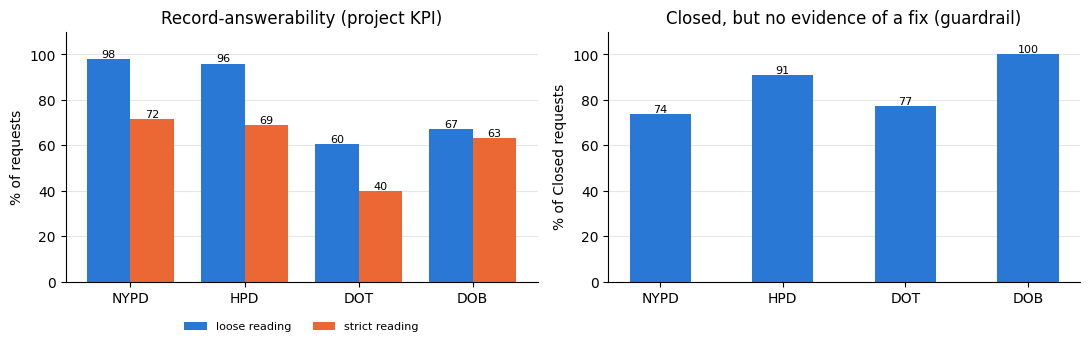

In [6]:
k = pd.read_csv(OUT / "kpi_by_agency.csv"); k = k[k.deep_dive == 1]
g = pd.read_csv(OUT / "guardrail_closed_without_fix.csv").set_index("agency")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
x = range(len(k)); w = 0.38
ax = axes[0]
b1 = ax.bar([i - w/2 for i in x], k.answerable_share * 100, w, color=BLUE, label="loose reading")
b2 = ax.bar([i + w/2 for i in x], k.answerable_share_strict * 100, w, color=ORANGE, label="strict reading")
ax.bar_label(b1, fmt="%.0f", fontsize=8); ax.bar_label(b2, fmt="%.0f", fontsize=8)
ax.set_xticks(list(x), k.agency); ax.set_ylim(0, 110); ax.set_ylabel("% of requests"); ax.set_title("Record-answerability (project KPI)")
ax.legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
ax = axes[1]
gv = g.loc[k.agency, "closed_without_fix_evidence"] * 100
b = ax.bar(k.agency, gv, color=BLUE, width=0.5); ax.bar_label(b, fmt="%.0f", fontsize=8)
ax.set_ylim(0, 110); ax.set_ylabel("% of Closed requests"); ax.set_title("Closed, but no evidence of a fix (guardrail)")
for a in axes:
    a.spines[["top", "right"]].set_visible(False); a.grid(axis="y", color="#e6e6e3", linewidth=0.8); a.set_axisbelow(True)
plt.tight_layout(); plt.show()

In [7]:
pd.read_csv(OUT / "evidence_table.csv")

,agency,requests,kpi_answerable,kpi_answerable_strict,kpi_unknown,kpi_fail,guardrail_closed_without_fix_evidence,open_next_step_rate,open_requests,open_longer_than_7d,main_blocker,main_blocker_share_of_requests,fix_owner
0,NYPD,460240,0.9803,0.7153,0.0000,0.0197,0.7378,0.8889,9,0.0000,A5,0.0197,"Agency + OTI (publish status in 311, not a separate site)"
1,HPD,159275,0.9596,0.6890,0.0152,0.0252,0.9084,0.9992,5151,0.4779,A5,0.0246,"Agency + OTI (publish status in 311, not a separate site)"
2,DOT,76000,0.6033,0.3978,0.0601,0.3366,0.7722,0.6031,4361,0.3551,A5,0.3225,"Agency + OTI (publish status in 311, not a separate site)"
3,DOB,30604,0.6693,0.6326,0.2073,0.1234,1.0000,0.6148,3759,0.5052,A3,0.2079,Agency (closing-note wording)


## 5. Decision by complaint type
The proposed decision uses the strict reading (90%+ candidate, 60 to 90% fix first, below 60% hold). The cross-table shows how much the call depends on how the closing notes are read.

In [8]:
t = pd.read_csv(OUT / "kpi_by_complaint_type.csv")
pd.crosstab(t.proposed_decision, t.decision_if_loose_reading, values=t.requests, aggfunc="sum", margins=True).fillna(0).astype(int)

decision_if_loose_reading,candidate for measurement pilot,fix blocker first,hold,All
proposed_decision,,,,
candidate for measurement pilot,12681,0,0,12681
fix blocker first,476978,53910,0,530888
hold,78246,65101,36033,179380
All,567905,119011,36033,722949


In [9]:
t.sort_values("answerable_share_strict")[["agency","complaint_type","requests","answerable_share","answerable_share_strict",
                                             "main_blocker","proposed_decision"]]

,agency,complaint_type,requests,answerable_share,answerable_share_strict,main_blocker,proposed_decision
10,DOT,Traffic Signal Condition,11581,0.0000,0.0000,A5,hold
11,DOT,Street Light Condition,8782,0.0000,0.0000,A5,hold
19,DOT,Broken Parking Meter,722,0.4931,0.0042,A5,hold
17,DOT,Street Sign - Dangling,1004,0.9243,0.0916,A3,hold
16,DOT,Highway Condition,1039,0.7738,0.1126,A3,hold
14,DOT,Street Sign - Damaged,1503,0.6979,0.1710,A3,hold
18,DOT,Street Sign - Missing,1003,0.7119,0.3101,A3,hold
15,DOT,Outdoor Dining,1299,0.3256,0.3256,A5,hold
2,DOB,Building/Use,6267,0.3976,0.3510,A2,hold
12,DOT,Sidewalk Condition,7191,0.6993,0.3514,A3,hold


## 6. The notes that decide it
Notes coded `medium` certainty count as UNKNOWN under the strict reading. A few of them cover most of the affected requests.

In [10]:
m = pd.read_csv(ROOT / "reference" / "closing_text_map_v2.csv", dtype=str)
m["rows"] = m.rows_in_2026Q2.astype(int)
med = m[m.certainty == "medium"].sort_values("rows", ascending=False)
print(len(med), "medium-certainty notes cover", f"{med.rows.sum():,}", "requests")
med[["agency","rows","fix_evidence","rationale"]].head(7)

21 medium-certainty notes cover 184,184 requests


,agency,rows,fix_evidence,rationale
33,NYPD,120685,yes,"Template says both 'no criminal violation' and 'condition was corrected'. Used on 120,..."
2,HPD,25416,unknown,Inspection not completed; resident told to file again.
6,HPD,7088,yes,Occupant confirmed heat/hot water restored.
52,DOT,6964,unknown,Duplicate; original 'being addressed'; original request key not given.
7,HPD,5949,no,Conditions still open; HPD 'may' call or inspect. Next step is conditional.
8,HPD,5331,yes,Someone at the phone number said it was corrected; not verified by inspection.
56,DOT,3597,unknown,Meets standards or has a valid permit.
